<a href="https://colab.research.google.com/github/Dhairya3103/movie-recommendation-website/blob/main/popularity_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load your cleaned dataset
df = pd.read_csv('cleaned_movies_data.csv')
print("Data loaded successfully!")

Data loaded successfully!


Preprocessing data

In [ ]:
def process_cast(cast_str):
    """Extracts top 3 actors and removes spaces in their names."""
    try:
        cast_dict = ast.literal_eval(cast_str)
        actors = list(cast_dict.values())[:3]
        return " ".join([actor.replace(" ", "") for actor in actors])
    except:
        return ""

In [ ]:
def process_companies(comp_str):
    """Extracts top 3 production companies and removes spaces."""
    try:
        if pd.isna(comp_str): return ""
        comps = [c.strip().replace(" ", "") for c in comp_str.split(',')]
        return " ".join(comps[:3])
    except:
        return ""

In [ ]:
# Apply the functions to create our text features
df['clean_cast'] = df['cast'].apply(process_cast)
df['clean_comp'] = df['production_companies'].apply(process_companies)

In [ ]:
df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,crew,tags,year,engagement_score,weighted_rating,popularity_category,overview_length,success_score,clean_cast,clean_comp
0,237000000,"Action, Adventure, Fantasy, Science Fiction",19995,"culture clash, future, space war, space colony...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom",...,"{'Editor': 'John Refoua', 'Production Design':...",action adventure fantasy science fiction cultu...,2009.0,84960.0,7.050468,Very High,28,48.828118,SamWorthington ZoeSaldana SigourneyWeaver,IngeniousFilmPartners TwentiethCenturyFoxFilmC...
1,300000000,"Adventure, Fantasy, Action",285,"ocean, drug abuse, exotic island, east india t...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,...,"{'Director of Photography': 'Dariusz Wolski', ...",adventure fantasy action ocean drug abuse exot...,2007.0,31050.0,6.665426,Very High,34,45.122943,JohnnyDepp OrlandoBloom KeiraKnightley,WaltDisneyPictures JerryBruckheimerFilms Secon...
2,245000000,"Action, Adventure, Crime",206647,"spy, based on novel, secret agent, sequel, mi6...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"Columbia Pictures, Danjaq, B24","United Kingdom, United States of America",...,"{'Original Music Composer': 'Thomas Newman', '...",action adventure crime spy based novel secret ...,2015.0,28135.8,6.239307,Very High,41,35.397641,DanielCraig ChristophWaltz LéaSeydoux,ColumbiaPictures Danjaq B24
3,250000000,"Action, Crime, Drama, Thriller",49026,"dc comics, crime fighter, terrorist, secret id...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",United States of America,...,"{'Original Music Composer': 'Hans Zimmer', 'Pr...",action crime drama thriller dc comic crime fig...,2012.0,69205.6,7.346396,Very High,65,37.499515,ChristianBale MichaelCaine GaryOldman,LegendaryPictures WarnerBros. DCEntertainment
4,260000000,"Action, Adventure, Science Fiction",49529,"based on novel, mars, medallion, space travel,...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,...,"{'Screenplay': 'Mark Andrews', 'Director': 'An...",action adventure science fiction based novel m...,2012.0,12956.4,6.096324,Very High,55,16.257151,TaylorKitsch LynnCollins SamanthaMorton,WaltDisneyPictures


In [ ]:
# Combine them into one column for the vectorizer
df['model_tags'] = df['clean_cast'] + " " + df['clean_comp']

Filter and clean dataset for prediction

In [ ]:
# Drop rows where we are missing crucial data
model_df = df.dropna(subset=['success_score', 'budget', 'runtime', 'model_tags']).copy()

In [ ]:
# Remove movies with 0 budget (these skew the machine learning model)
model_df = model_df[model_df['budget'] > 0]
print(f"Data filtered. Remaining movies for training: {model_df.shape[0]}")

Data filtered. Remaining movies for training: 3762


Vectorize the text

In [ ]:
# We only learn the Top 100 most frequent actors/companies to save memory
vectorizer = CountVectorizer(max_features=100)

# Convert the text tags into a matrix of 1s and 0s
cat_features = vectorizer.fit_transform(model_df['model_tags']).toarray()

# Turn that matrix into a DataFrame
cat_df = pd.DataFrame(cat_features, columns=vectorizer.get_feature_names_out(), index=model_df.index)

In [ ]:
# Combine numerical features (budget, runtime) with our 1s and 0s (actors/companies)
X = pd.concat([model_df[['budget', 'runtime']], cat_df], axis=1)
y = model_df['success_score']

Train-Test split and Train Model

In [ ]:
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training data size: {X_train.shape[0]} movies")
print(f"Testing data size: {X_test.shape[0]} movies")

Training data size: 3009 movies
Testing data size: 753 movies


In [ ]:
print("Training the Random Forest Model... (this might take a few seconds)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training the Random Forest Model... (this might take a few seconds)


RandomForestRegressor(random_state=42)

Evaluate the model

In [ ]:
y_pred = rf_model.predict(X_test)
print("\n--- Model Performance ---")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")


--- Model Performance ---
Mean Squared Error: 71.98
R-squared Score: -0.00


Feature Importance Analysis

In [ ]:
# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Get feature names from the training data (X_train columns)
feature_names = X_train.columns

# Create a pandas Series for better visualization and sorting
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance_df = importance_df.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances:")
print(sorted_importance_df.head(10))

Top 10 Feature Importances:
budget                                0.400939
runtime                               0.200939
matthewmcconaughey                    0.058970
sandrabullock                         0.048516
universalpictures                     0.034436
legendarypictures                     0.023567
amblinentertainment                   0.019290
paramountpictures                     0.018048
warnerbros                            0.017057
twentiethcenturyfoxfilmcorporation    0.013076
dtype: float64


Let's visualize the top 10 feature importances to get a clearer picture.

/tmp/ipykernel_3083/1540632591.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance_df.head(10).values, y=sorted_importance_df.head(10).index, palette='viridis')


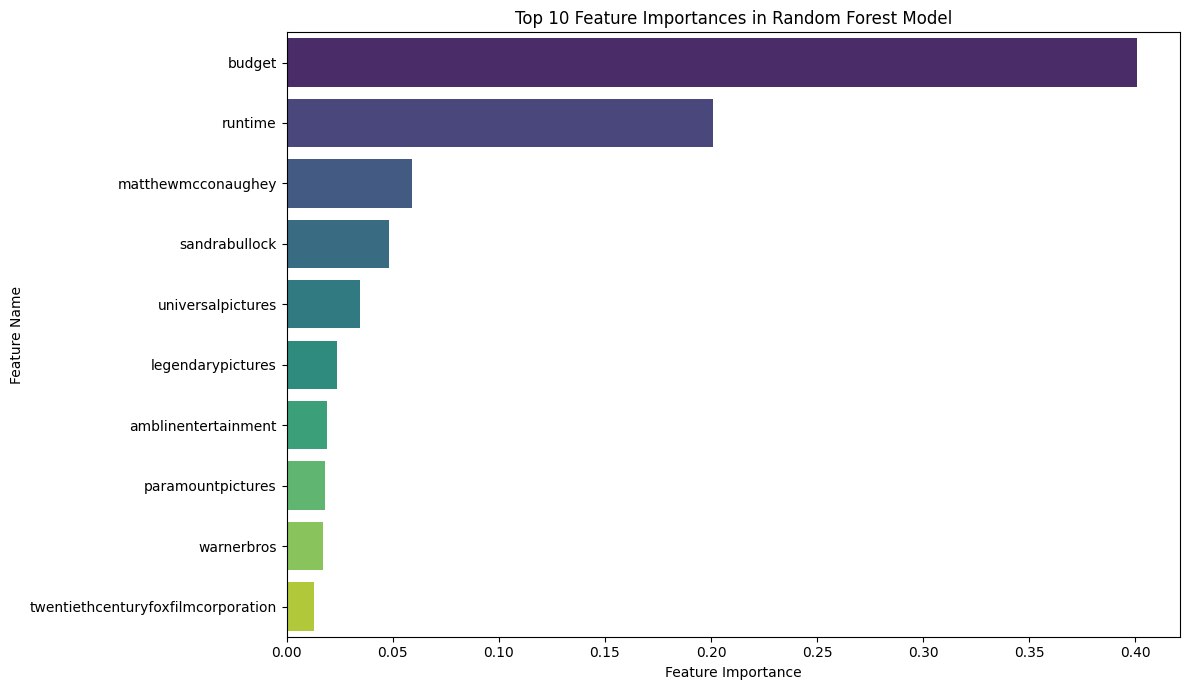

In [ ]:
# Visualize the top 10 feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importance_df.head(10).values, y=sorted_importance_df.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Export files

In [ ]:
# Save the trained model
pickle.dump(rf_model, open('popularity_model.pkl', 'wb'))

# Save the vectorizer (CRITICAL for the web app to process user input)
pickle.dump(vectorizer, open('popularity_vectorizer.pkl', 'wb'))